In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor

In [3]:
train_df = pd.read_csv('Final_Train.csv')
test_df = pd.read_csv('Final_Test.csv')

In [4]:
target = 'price'

X_train = train_df.drop(columns = [target])
y_train = train_df[target]

X_test = test_df.drop(columns = [target])
y_test = test_df[target]

In [5]:
xgb_model = XGBRegressor(n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
                  )

In [6]:
xgb_model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [8]:
pred = xgb_model.predict(X_test)

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
print ('MAE: ', mean_absolute_error(pred, y_test))
print ('\n')
print ('MSE: ', mean_squared_error(pred, y_test))
print ('\n')
print ('RSS: ', r2_score(pred, y_test))

MAE:  34382.54100147914


MSE:  5968942726.481047


RSS:  0.9565968133082723


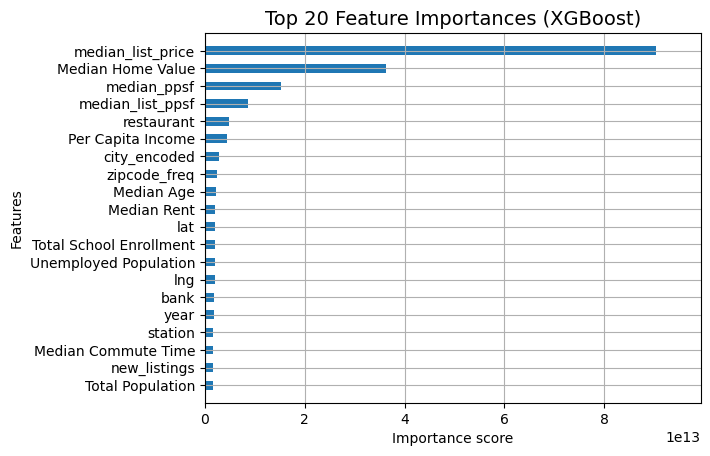

In [10]:
# Plot importances
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(
    xgb_model,
    importance_type="gain",
    max_num_features=20,
    height=0.5,
    show_values=False
)
plt.title("Top 20 Feature Importances (XGBoost)", fontsize=14)
plt.show()